#Conexión a Drive e importacion de librerias.


In [158]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [159]:
#librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
df = pd.read_csv('/content/drive/MyDrive/Archivos csv ciencia de datos/datos_tratados.csv')

In [161]:
df.sample(10)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
4259,5997-OPVFA,No,Male,No,Yes,No,72,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),2.97,89.05,6254.45
163,0265-EDXBD,Yes,Male,Yes,Yes,No,32,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,2.50,74.90,2303.35
3829,5380-XPJNZ,No,Female,No,No,No,38,Yes,No,No,...,No,No,No,No,One year,No,Mailed check,0.67,20.05,678.20
50,0083-PIVIK,No,Male,No,No,No,64,Yes,Yes,DSL,...,Yes,Yes,Yes,No,One year,No,Electronic check,2.71,81.25,5567.55
4020,5668-MEISB,No,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),3.54,106.10,7657.40
2634,3746-EUBYR,Yes,Male,No,Yes,No,1,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),2.49,74.60,74.60
893,1302-UHBDD,No,Male,Yes,No,No,20,Yes,No,Fiber optic,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,3.00,89.95,1648.45
1014,1465-VINDH,Yes,Female,No,Yes,Yes,10,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),3.40,102.10,1068.85
3705,5214-CHIWJ,No,Male,No,No,No,27,Yes,No,No,...,No,No,No,No,One year,No,Mailed check,0.68,20.30,595.05
3801,5346-BZCHP,No,Female,No,Yes,Yes,69,Yes,No,No,...,No,No,No,No,Two year,No,Mailed check,0.65,19.40,1346.20


In [162]:
df= df.drop(columns=['CustomerID'])

##Exploración de los datos

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [164]:
cols = [
    'StreamingTV',
    'StreamingMovies',
    'DeviceProtection',
    'TechSupport',
    'OnlineSecurity',
    'OnlineBackup'
]

for col in cols:
    df[col] = df[col].fillna('No internet service')

In [165]:
cols_tofix = [
    'StreamingTV',
    'StreamingMovies',
    'DeviceProtection',
    'TechSupport',
    'OnlineSecurity',
    'OnlineBackup'
]

for col in cols_tofix:
    df[col] = df[col].replace('No internet service', 'No')

In [166]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [167]:
df.sample(10)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
5466,Yes,Male,No,Yes,Yes,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,2.67,80.15,385.00
6979,No,Female,Yes,No,No,65,No,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),1.78,53.50,3517.90
6611,No,Male,No,No,Yes,27,Yes,No,No,No,...,No,No,No,No,Two year,No,Mailed check,0.69,20.60,581.85
6613,No,Female,No,No,No,69,Yes,Yes,No,No,...,No,No,No,No,Two year,No,Credit card (automatic),0.82,24.60,1678.05
4934,No,Male,No,Yes,Yes,54,Yes,No,Fiber optic,No,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),2.66,79.95,4362.05
6659,Yes,Female,No,No,No,15,Yes,No,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,1.98,59.45,892.65
416,Yes,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),2.51,75.20,3678.30
3530,No,Female,No,Yes,Yes,67,No,No,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),1.81,54.20,3623.95
1880,Yes,Male,No,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.02,90.75,90.75
3596,No,Female,No,Yes,No,55,Yes,No,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,1.89,56.80,3112.05


##EDA (revisión de correlación entre las columnas)

In [168]:
import plotly.express as px

In [169]:
px.histogram(df, x = 'Churn', text_auto=True)

In [170]:
px.histogram(df, x = 'Churn', color = 'Gender', text_auto=True)

In [171]:
px.histogram(df, x = 'Churn', color = 'Contract', text_auto=True)

In [172]:
px.histogram(df, x = 'Churn', color = 'InternetService', text_auto=True)

In [173]:
px.histogram(df, x='Churn', color= 'PaymentMethod', text_auto=True)

In [174]:
px.histogram(df, x = 'Churn', color = 'StreamingTV', text_auto=True)

In [175]:
px.histogram(df, x = 'Churn', color = 'StreamingMovies', text_auto=True)

In [176]:
px.histogram(df, x = 'Churn', color = 'MultipleLines', text_auto=True)

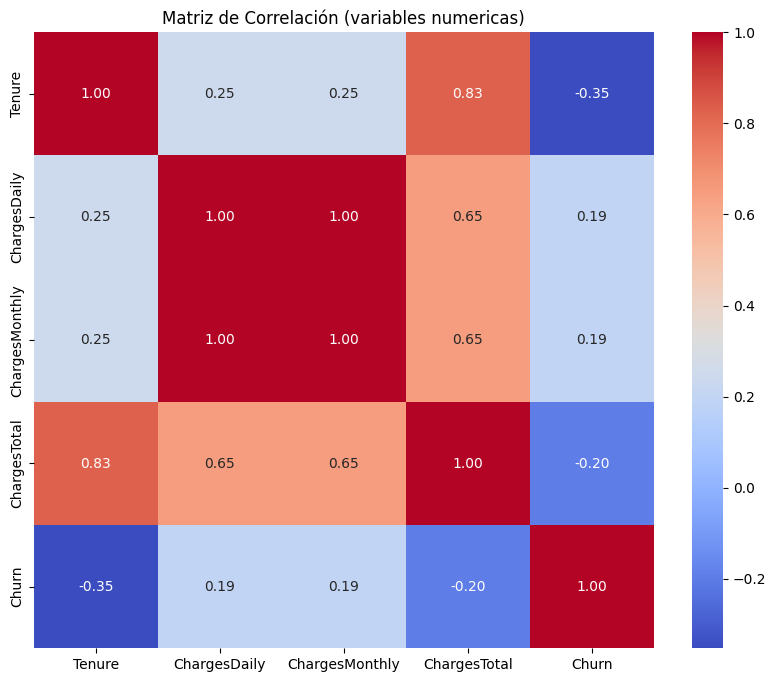

In [177]:
df_nums = df.select_dtypes(include=['float64', 'int64'])

df_nums['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr_matrix = df_nums.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (variables numericas)')
plt.show()

###Nota
Las variables dependientes al tiempo como el cargo total y el cargo diario (que son lo mismo pero dividido) tienen una alta correlación, basando se en el mapa de calor.
En  este caso se eliminan las columnas que hacen referencia al total y a los cargos diarios para no generar multicolinealidad en el modelo

In [178]:
df =  df.drop(columns=['ChargesDaily', 'ChargesTotal'])

##Analisis de las variables categoricas con el Churn

###Seleccion de las variables categoricas.


In [179]:
Cat_cols =  df.select_dtypes(include=['object']).columns
Cat_cols = Cat_cols.drop('Churn')

###Tablas de proporción categorica:

In [180]:
for col in Cat_cols:
    print(f'\n Analisis de la variable: {col}')
    display(pd.crosstab(df[col], df['Churn'], normalize='index')*100)


 Analisis de la variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 Analisis de la variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 Analisis de la variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 Analisis de la variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 Analisis de la variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


##Nota.
En el caso de las variables categoricas se debe analizar cuales tienen un menor peso con respecto al churn, en este caso son genero y el servicio telefonico

In [181]:
df =  df.drop(columns=['Gender', 'PhoneService'])

##División de los datos/split (conjuntos de entrenamiento y de prueba)

In [182]:
X = df.drop('Churn', axis=1)
y = df['Churn']



In [183]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Encoding de los datos

In [184]:
X_train = pd.get_dummies(X_train, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='inner', axis=1)

In [185]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [186]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

##Revisión del desbalance de las clases en los conjuntos

In [187]:
y_train.value_counts(normalize= True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


#Entrenamiento de los modelos.

##Modelo: random forest

In [188]:
from sklearn.ensemble import RandomForestClassifier

rf_under = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_under.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [189]:
y_pred = rf_under.predict(X_test)

In [190]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [191]:
from sklearn.metrics import roc_auc_score

y_proba = rf_under.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_proba)

np.float64(0.8180319822263556)

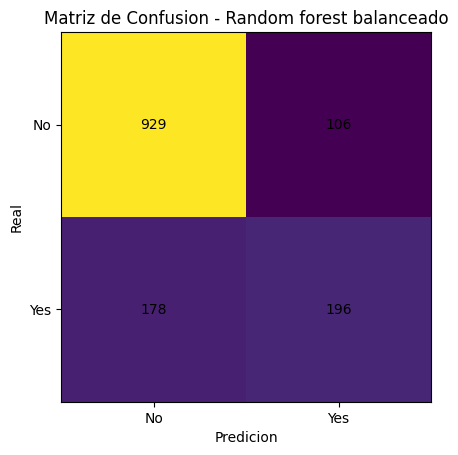

In [211]:
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Random forest balanceado")
plt.xlabel("Predicion")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

##Modelo: dummy

In [193]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [194]:
y_pred_dummy = dummy_clf.predict(X_test)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:,1]

In [195]:
print('Dummy Classifier')
print(classification_report(y_test, y_pred_dummy))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba_dummy)}')

Dummy Classifier
              precision    recall  f1-score   support

          No       0.73      1.00      0.85      1035
         Yes       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

ROC AUC: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



##Modelo: Arbol de decisión.

In [196]:
from sklearn.tree import DecisionTreeClassifier

dt_under = DecisionTreeClassifier(max_depth = 10,random_state=42)
dt_under.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [197]:
y_pred_arbol =  dt_under.predict(X_test)
y_probaarbol = dt_under.predict_proba(X_test)[:,1]

In [198]:
print("DECISION TREE")
print(classification_report(y_test, y_pred_arbol))
print("ROC AUC:", roc_auc_score(y_test, y_probaarbol))

DECISION TREE
              precision    recall  f1-score   support

          No       0.82      0.84      0.83      1035
         Yes       0.53      0.49      0.51       374

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409

ROC AUC: 0.7465305226174792


##Modelo KNN

In [199]:
from sklearn.preprocessing import MinMaxScaler

In [200]:
from sklearn.impute  import SimpleImputer

imputer  = SimpleImputer(strategy='mean')
X_train_imp =  imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

norm =  MinMaxScaler()
X_train_norm = norm.fit_transform(X_train_imp)



In [201]:
pd.DataFrame(X_train_norm)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.833333,0.754360,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.166667,0.009467,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.027778,0.618336,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.458333,0.561535,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.194444,0.673642,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.305556,0.023418,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5630,0.583333,0.755356,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5631,0.277778,0.666168,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5632,0.333333,0.062780,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [202]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [203]:
knn.fit(X_train_norm, y_train)

KNeighborsClassifier()

In [204]:
X_test_imp = imputer.transform(X_test)
X_test_norm = norm.transform(X_test_imp)

In [205]:
knn.score(X_test_norm, y_test)

0.759403832505323

In [206]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predicciones
y_pred_knn = knn.predict(X_test_norm)
y_proba_knn = knn.predict_proba(X_test_norm)[:, 1]

print("KNN Classifier")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_knn)}")

KNN Classifier
              precision    recall  f1-score   support

          No       0.82      0.86      0.84      1035
         Yes       0.55      0.48      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.75      1409

Confusion Matrix:
[[890 145]
 [194 180]]
ROC AUC: 0.7804864501795448


##Modelo: Regresión logistica

In [207]:
from sklearn.linear_model import LogisticRegression

lr_under = LogisticRegression(max_iter = 1000)
lr_under.fit(X_train, y_train)

y_pred =  lr_under.predict(X_test)

print('Reg. Logistica')
print(classification_report(y_test, y_pred))

Reg. Logistica
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [208]:
from sklearn.linear_model import LogisticRegression

lr_under = LogisticRegression(max_iter = 1000, class_weight='balanced')
lr_under.fit(X_train, y_train)

y_pred_log =  lr_under.predict(X_test)

print('Reg. Logistica balanceada')
print(classification_report(y_test, y_pred))

Reg. Logistica balanceada
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



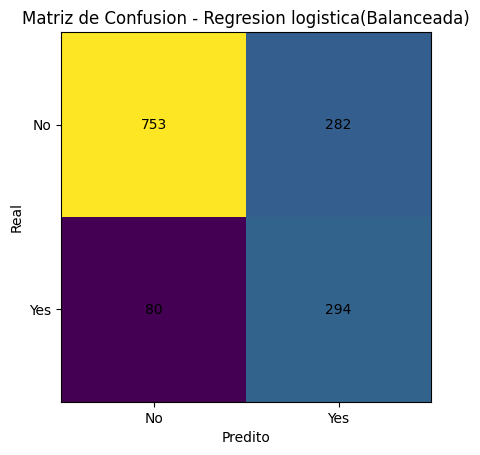

In [209]:
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

#Analisis de las variables.


In [215]:
from sklearn.inspection import permutation_importance

result = permutation_importance(lr_under, X_test, y_test, n_repeats=10, random_state=42 )
importance = pd.DataFrame({ "Variable": X_test.columns, "Importancia": result.importances_mean }).sort_values(by="Importancia", ascending=False)
importance.head(10)

,Variable,Importancia
0,Tenure,0.034067
6,InternetService_Fiber optic,0.024060
1,ChargesMonthly,0.019659
7,InternetService_No,0.018453
14,Contract_One year,0.009226
8,OnlineSecurity_Yes,0.001632
12,StreamingTV_Yes,0.001632
19,PaymentMethod_Mailed check,0.000994
17,PaymentMethod_Credit card (automatic),0.000497
11,TechSupport_Yes,0.000284


#Conclusión.


##1. Modelo.
El modelo seleccionado fue el Modelo de Regresión logistica, aunque en el cuadro de reporte de clasificación no tuvo un desempeño notable, al evaluar con una matriz de confusión esta tuvo un mejor resultado, reduciendo el numero de falsos positivos hasta casi un tercio de los positivos verdaderos. En comparación los modelos KNN, Random Forest y Decidion tree; tuvieron un desempeño menor a la regresión logistica.

#2. Variables.
La cancelación del servicio provisto por Telecom X está sujeto a las siguientes variables:
Tenure.
InternetService_Fiber optic.
ChargesMonthly.
Contract_One year.

Ternure, que refiere a la duración del contrato de los clientes es la variable con mayor peso en este analisis. Cuando un cliente tiene menor tiempo utilizando el servicio, hablando en terminos mensuales, estos tienden a cancelar con mayor frecuencia.

Fibra optica. relacionado con el punto siguiente, esto puede deberse a un mayor costo para lo clientes que cuentan con una instalación que utiliza fibra optica.

Cargos mensuales. Un cargo mayor en un periodo de un mes se relaciona fuertemente con la cancelación del servicio, a mayor costo mensual, menor retención de clientes; este punto y el anterior se relacionan de la siguiente manera. Si la utilización de fibra optica involucra un cargo mayor para los clientes, estos puedes verse menos motivados a conservar el servicio en relacion a los beneficios que la fibra optica les pueda proveer.

Tipo de contrato: mensual.
en el caso de los contratos de un año en adelante,esto refleja que los clientes que pasan un mayor tiempo utilizando el servicio de Telecom X tienden a no cancelar sus servicios sino a permanecer con  el contrato que tienen.


#3. propuestas.
Para que la tasa de cancelación de Telecom X disminuya, se proponen 3 posibles soluciones basadas en los resultados del modelo, matriz de confusión y variables relacionadas.

1. Beneficios iniciales durante periodos de uno a tres meses.
2. Mejora de los servicios complementarios con almacenamiento en la nube o mayor cantidad de MB disponibles para el uso de los clientes
3. disolución del tipo de contrato mensual, aumentando el tiempo de permanencia de los usuarios, en su lugar podria cambiarse el contrato mensual por un plan basado en el consumo del servicio.